In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Crop_recommendation.csv"

# Load the latest version
data = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "atharvaingle/crop-recommendation-dataset",
  file_path,
)

data.head()

/tmp/ipython-input-3577860742.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  data = kagglehub.load_dataset(


Using Colab cache for faster access to the 'crop-recommendation-dataset' dataset.


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [26]:
data.shape

(2200, 8)

## **Data Visualisation**

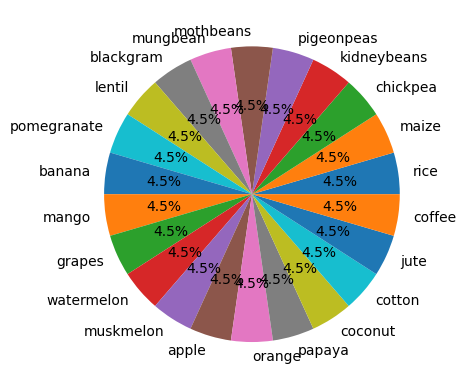

In [9]:
labels = data['label'].unique()
plt.pie(data['label'].value_counts(), labels=labels, autopct='%1.1f%%')
plt.show()

In [41]:
data['K'].describe(), data['N'].describe(), data['P'].describe(),

(count    2200.000000
 mean       48.149091
 std        50.647931
 min         5.000000
 25%        20.000000
 50%        32.000000
 75%        49.000000
 max       205.000000
 Name: K, dtype: float64,
 count    2200.000000
 mean       50.551818
 std        36.917334
 min         0.000000
 25%        21.000000
 50%        37.000000
 75%        84.250000
 max       140.000000
 Name: N, dtype: float64,
 count    2200.000000
 mean       53.362727
 std        32.985883
 min         5.000000
 25%        28.000000
 50%        51.000000
 75%        68.000000
 max       145.000000
 Name: P, dtype: float64)

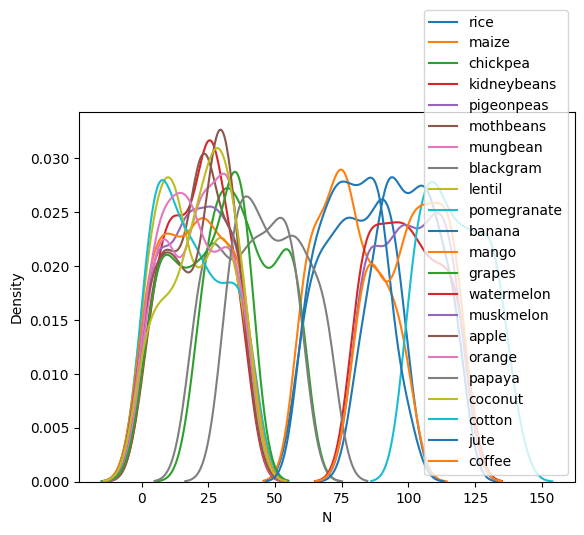

In [10]:
# Comparative analysis of each crop
for crop in labels:
    sns.kdeplot(data[data['label'] == crop]['N'], label=crop)
plt.legend()
plt.show()

## **Data featuring**

In [14]:
X = data.drop('label', axis=1)
Y = data['label']
X.head(), Y.head()

(    N   P   K  temperature   humidity        ph    rainfall
 0  90  42  43    20.879744  82.002744  6.502985  202.935536
 1  85  58  41    21.770462  80.319644  7.038096  226.655537
 2  60  55  44    23.004459  82.320763  7.840207  263.964248
 3  74  35  40    26.491096  80.158363  6.980401  242.864034
 4  78  42  42    20.130175  81.604873  7.628473  262.717340,
 0    rice
 1    rice
 2    rice
 3    rice
 4    rice
 Name: label, dtype: object)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [15]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)
X_scaled

array([[ 1.0687974 , -0.34455075, -0.1016875 , ...,  0.47266646,
         0.04330173,  1.8103605 ],
       [ 0.93332887,  0.14061552, -0.14118477, ...,  0.39705125,
         0.73487256,  2.24205791],
       [ 0.25598625,  0.04964684, -0.08193887, ...,  0.48695381,
         1.77151047,  2.92106603],
       ...,
       [ 1.82742114, -0.61745677, -0.35841972, ..., -0.19123516,
        -0.13812031,  1.27141766],
       [ 1.80032743, -0.64777967, -0.27942519, ..., -0.86951801,
         0.37390383,  0.43154519],
       [ 1.44810927, -1.07230015, -0.35841972, ..., -0.49802006,
         0.40109573,  0.68200518]])

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((1760, 7), (440, 7), (1760,), (440,))

## **Model**

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

In [27]:
def evaluate_model(model, X, Y):
    Y_pred = model.predict(X)
    print("Calssification Report: \n")
    print(classification_report(Y, Y_pred))
    print("Confusion Matrix: \n")
    sns.heatmap(confusion_matrix(Y, Y_pred))

#### **Nb**

In [19]:
from sklearn.naive_bayes import GaussianNB

Calssification Report: 

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        17
   blackgram       1.00      1.00      1.00        19
    chickpea       1.00      1.00      1.00        18
     coconut       1.00      1.00      1.00        18
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        21
      grapes       1.00      1.00      1.00        14
        jute       0.86      1.00      0.92        18
 kidneybeans       1.00      1.00      1.00        27
      lentil       1.00      1.00      1.00        19
       maize       1.00      1.00      1.00        17
       mango       1.00      1.00      1.00        21
   mothbeans       1.00      1.00      1.00        17
    mungbean       1.00      1.00      1.00        27
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        23
  

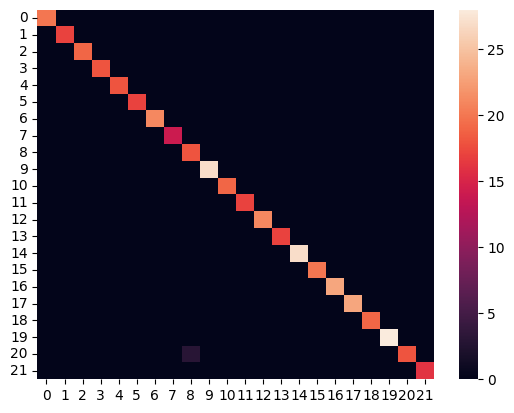

In [28]:
nb = GaussianNB()
nb.fit(X_train, Y_train)
evaluate_model(nb, X_test, Y_test)

### **KNNclf**

In [29]:
from sklearn.neighbors import KNeighborsClassifier

Calssification Report: 

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        17
   blackgram       0.95      1.00      0.97        19
    chickpea       1.00      1.00      1.00        18
     coconut       0.95      1.00      0.97        18
      coffee       1.00      0.94      0.97        17
      cotton       1.00      1.00      1.00        21
      grapes       1.00      1.00      1.00        14
        jute       0.75      1.00      0.86        18
 kidneybeans       1.00      1.00      1.00        27
      lentil       0.90      0.95      0.92        19
       maize       1.00      1.00      1.00        17
       mango       1.00      1.00      1.00        21
   mothbeans       1.00      0.88      0.94        17
    mungbean       1.00      1.00      1.00        27
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.83      0.90        23
  

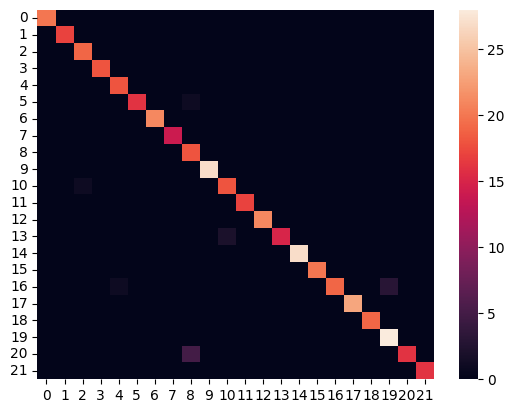

In [30]:
knn = KNeighborsClassifier()
knn.fit(X_train, Y_train)
evaluate_model(knn, X_test, Y_test)

##### **Choosing NB Classifier as the best model**

In [31]:
from sklearn.pipeline import Pipeline

In [32]:
pipe = Pipeline([('scaler', StandardScaler()), ('nb', GaussianNB())])
pipe.fit(X_train, Y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('nb', GaussianNB())])

In [39]:
pipe.predict([X_test[0]])

array(['lentil'], dtype='<U11')

In [42]:
import joblib

In [43]:
joblib.dump(pipe, "recc_pipe.pkl")

['recc_pipe.pkl']